In [12]:
from sklearn.datasets import load_files
import pandas as pd
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,StandardScaler
dataset=pd.read_csv("german_credit_data.csv")
#dataset.info()
#dataset['Risk'].value_counts()
#dataset.dropna()
dataset.shape
#dataset.describe(include="all").T
dataset.isna().sum()
dataset.dropna().reset_index(drop=True)
dataset.drop(columns="Unnamed: 0", inplace= True)
dataset.columns



Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='str')

In [13]:
numerical_cols = ['Age', 'Job', 'Credit amount', 'Duration']
nominal_cols = ['Sex', 'Housing', 'Purpose','Risk']
df=dataset[numerical_cols+nominal_cols]
df


,Age,Job,Credit amount,Duration,Sex,Housing,Purpose,Risk
0,67,2,1169,6,male,own,radio/TV,good
1,22,2,5951,48,female,own,radio/TV,bad
2,49,1,2096,12,male,own,education,good
3,45,2,7882,42,male,free,furniture/equipment,good
4,53,2,4870,24,male,free,car,bad
...,...,...,...,...,...,...,...,...
995,31,1,1736,12,female,own,furniture/equipment,good
996,40,3,3857,30,male,own,car,good
997,38,2,804,12,male,own,radio/TV,good
998,23,2,1845,45,male,free,radio/TV,bad


In [14]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,StandardScaler

le=LabelEncoder()
risk_vals=df['Risk'].values
le.fit_transform(risk_vals)

array([1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1,

,Age,Credit amount,Duration
Risk,,,
bad,33.963333,3938.126667,24.860000
good,36.224286,2985.457143,19.207143


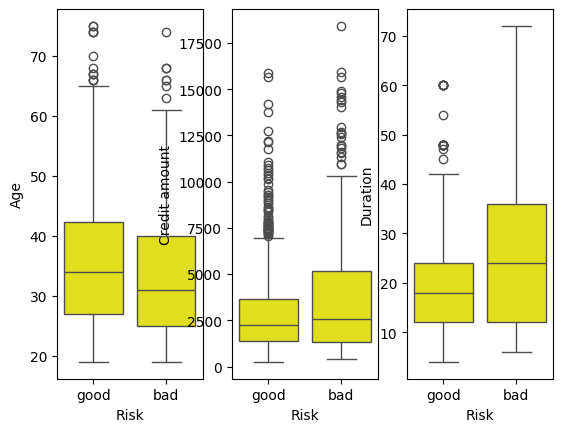

In [15]:
df["Purpose"].unique()
import matplotlib.pyplot as plt
import seaborn as sns
for i, col in enumerate(['Age', 'Credit amount', 'Duration']):
    plt.subplot(1,3,i+1)
    sns.boxplot(data=df, x='Risk', y=col, color='Yellow')
df.groupby('Risk')[['Age','Credit amount', 'Duration']].mean()


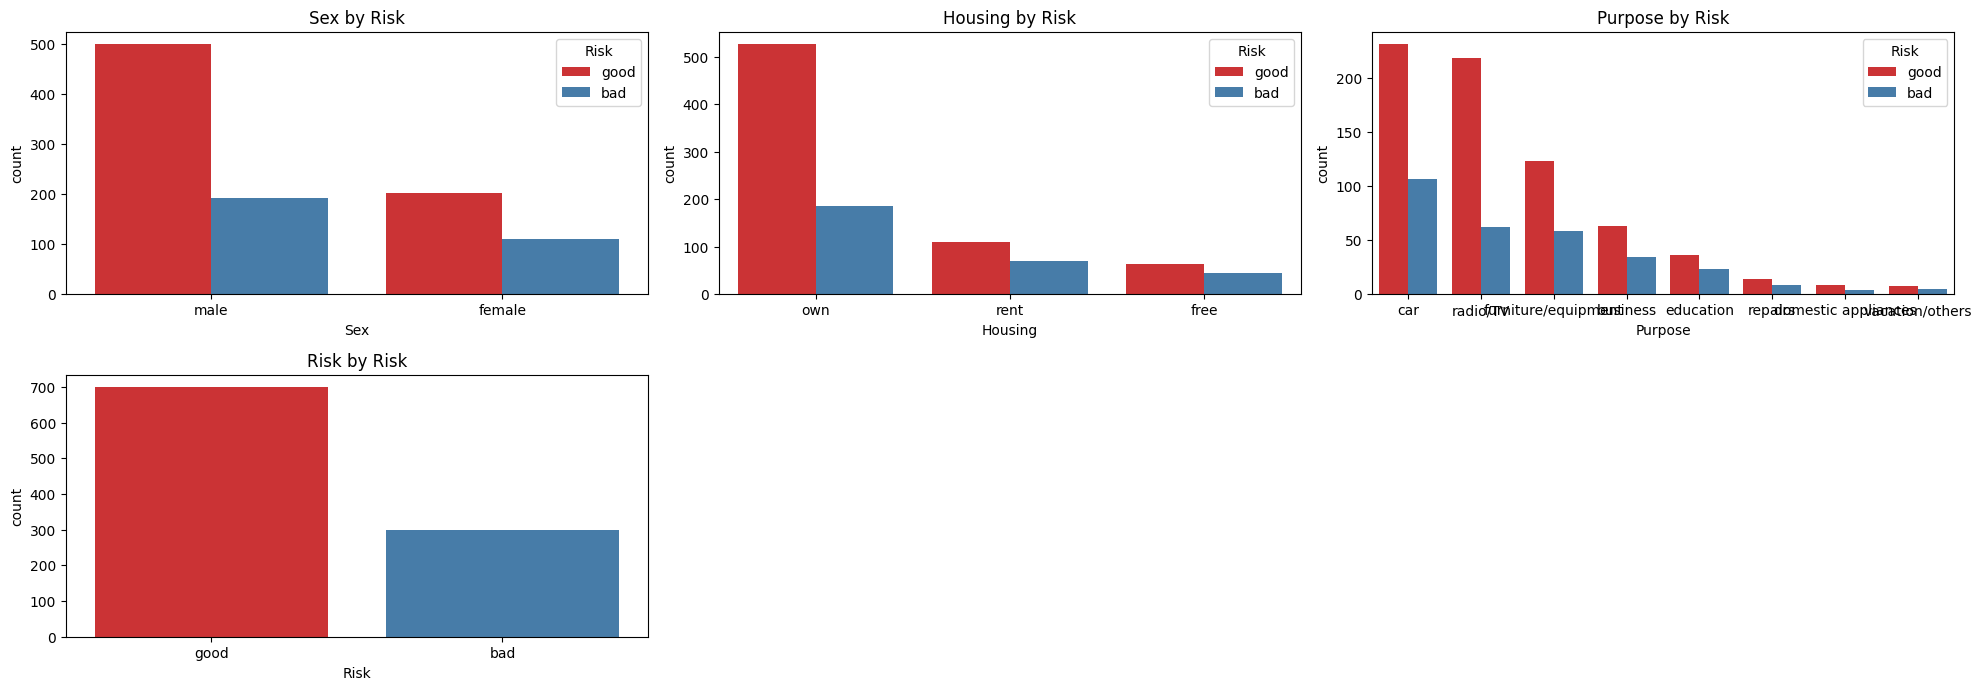

In [16]:
plt.figure(figsize=(20,10))
for i, col in enumerate(nominal_cols):
    plt.subplot(3,3, i+1)
    sns.countplot(data=df, x=col, hue='Risk', palette='Set1', order=df[col].value_counts().index)
    plt.title("Value counts by risk")
    plt.title(f"{col} by Risk")
plt.tight_layout()

In [17]:
df.dropna().reset_index(drop=True)
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse_output=False, drop='first')
encoded_nom = ohe.fit_transform(df[nominal_cols])
encoded_nom_df = pd.DataFrame(
    encoded_nom,
    columns=ohe.get_feature_names_out(nominal_cols))
df_final = pd.concat([df[numerical_cols], encoded_nom_df], axis=1)

In [18]:
scaler=StandardScaler()
scaler.fit_transform(df_final)
df_final

,Age,Job,Credit amount,Duration,Sex_male,Housing_own,Housing_rent,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others,Risk_good
0,67,2,1169,6,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,22,2,5951,48,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,49,1,2096,12,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,45,2,7882,42,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,53,2,4870,24,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,31,1,1736,12,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
996,40,3,3857,30,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
997,38,2,804,12,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
998,23,2,1845,45,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [19]:
df_final.shape

(1000, 15)

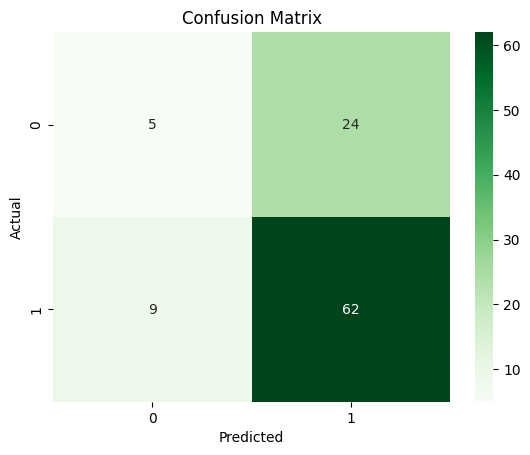

In [32]:
from sklearn.model_selection import train_test_split
X = df_final.drop(columns=['Risk_good'])
y = df_final['Risk_good']
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.20, random_state=0)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=0)
from sklearn.neighbors import KNeighborsClassifier
model=KNeighborsClassifier(n_neighbors=10, algorithm="auto",leaf_size=30)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
y_pred
score=model.score(X_test,y_test)
score
from sklearn.metrics import confusion_matrix
matrix=confusion_matrix(y_test,y_pred)
tn,fp,fn,tp=matrix.ravel()

#import seaborn
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(matrix, annot=True, fmt="d", cmap="Greens")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

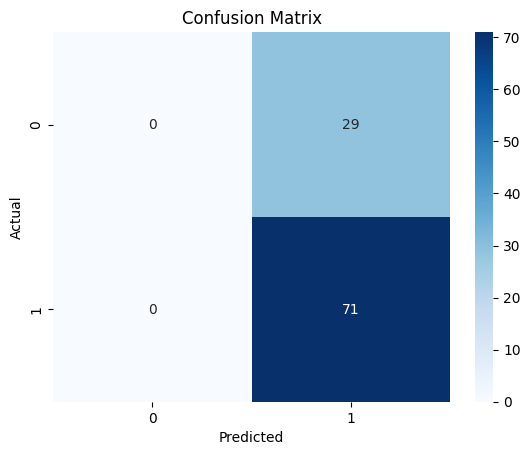

In [33]:
from sklearn.svm import SVC
model=SVC(kernel="sigmoid", C=4, gamma=0.4)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
y_pred
score=model.score(X_test,y_test)
score
from sklearn.metrics import confusion_matrix
matrix=confusion_matrix(y_test,y_pred)
tn,fp,fn,tp=matrix.ravel()

#import seaborn
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()